In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch

In [2]:
df = pd.read_csv("Wholesale customers data.csv")
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [3]:
df.head(10)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
5,2,3,9413,8259,5126,666,1795,1451
6,2,3,12126,3199,6975,480,3140,545
7,2,3,7579,4956,9426,1669,3321,2566
8,1,3,5963,3648,6192,425,1716,750
9,2,3,6006,11093,18881,1159,7425,2098


In [4]:
df.tail(10)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
430,1,3,3097,4230,16483,575,241,2080
431,1,3,8533,5506,5160,13486,1377,1498
432,1,3,21117,1162,4754,269,1328,395
433,1,3,1982,3218,1493,1541,356,1449
434,1,3,16731,3922,7994,688,2371,838
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125
439,1,3,2787,1698,2510,65,477,52


In [5]:
print("Rows and Columns:", df.shape)

Rows and Columns: (440, 8)


In [6]:
df.columns

Index(['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicassen'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [8]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [9]:
df.isnull().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

In [10]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [11]:
df = df.drop_duplicates()

In [12]:
df.shape

(440, 8)

In [14]:
df.dtypes

Channel             int64
Region              int64
Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
Delicassen          int64
dtype: object

In [15]:
df.sample(10)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
74,2,3,8190,6343,9794,1285,1901,1780
113,1,3,14438,2295,1733,3220,585,1561
379,2,3,4048,5164,10391,130,813,179
287,1,3,15354,2102,2828,8366,386,1027
271,1,1,2083,5007,1563,1120,147,1550
391,1,3,2647,2761,2313,907,95,1827
387,1,3,20918,1916,1573,1960,231,961
273,1,3,36817,3045,1493,4802,210,1824
397,1,3,11535,1666,1428,6838,64,743
229,1,1,8656,2746,2501,6845,694,980


In [16]:
for col in df.columns:
    print(col, ":", df[col].nunique())

Channel : 2
Region : 3
Fresh : 433
Milk : 421
Grocery : 430
Frozen : 426
Detergents_Paper : 417
Delicassen : 403


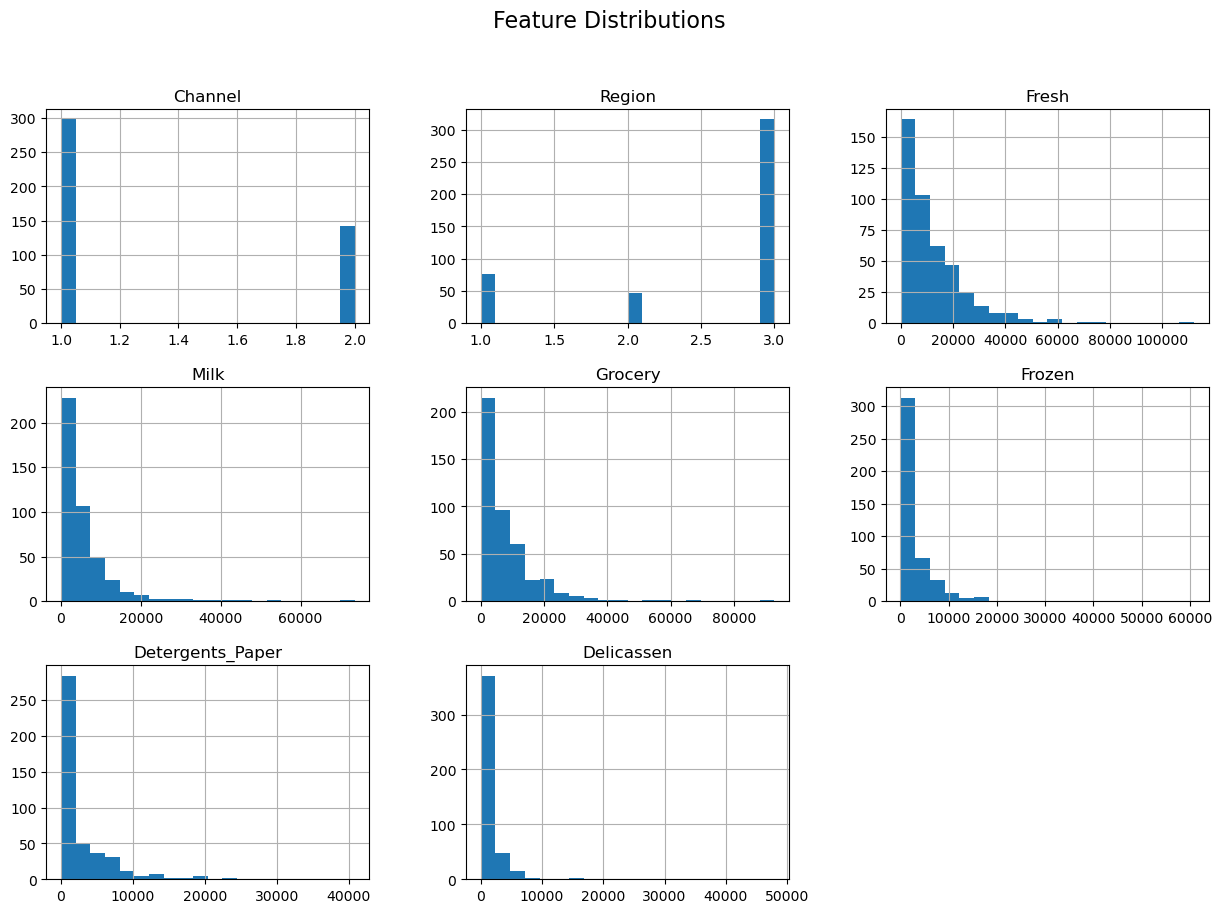

In [17]:
df.hist(figsize=(15,10), bins=20)

plt.suptitle("Feature Distributions", fontsize=16)

plt.show()

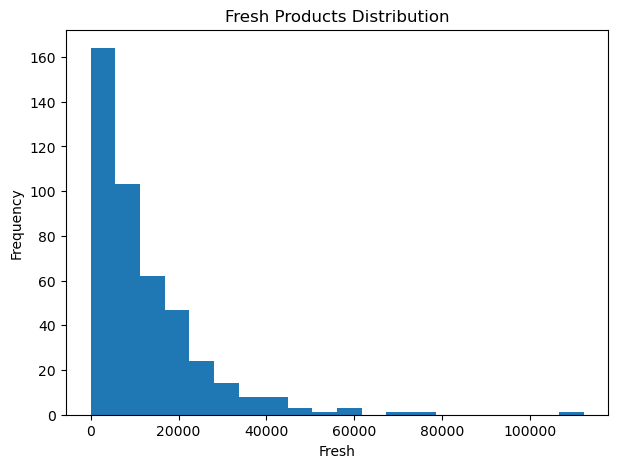

In [19]:
plt.figure(figsize=(7,5))
plt.hist(df["Fresh"], bins=20)
plt.title("Fresh Products Distribution")
plt.xlabel("Fresh")
plt.ylabel("Frequency")
plt.show()

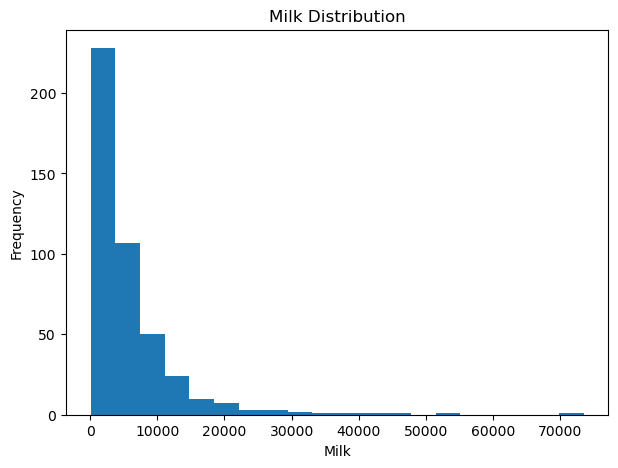

In [23]:
plt.figure(figsize=(7,5))
plt.hist(df["Milk"], bins=20)
plt.title("Milk Distribution")
plt.xlabel("Milk")
plt.ylabel("Frequency")
plt.show()

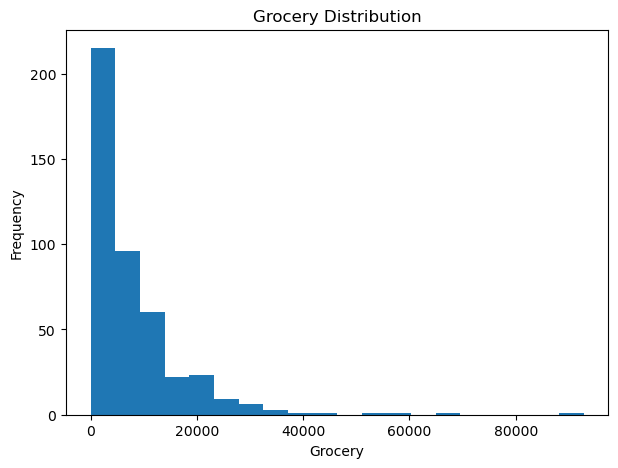

In [24]:
plt.figure(figsize=(7,5))
plt.hist(df["Grocery"], bins=20)
plt.title("Grocery Distribution")
plt.xlabel("Grocery")
plt.ylabel("Frequency")
plt.show()

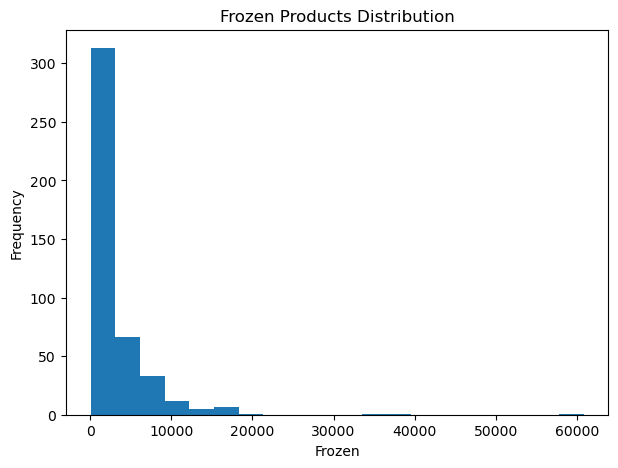

In [25]:
plt.figure(figsize=(7,5))
plt.hist(df["Frozen"], bins=20)
plt.title("Frozen Products Distribution")
plt.xlabel("Frozen")
plt.ylabel("Frequency")
plt.show()

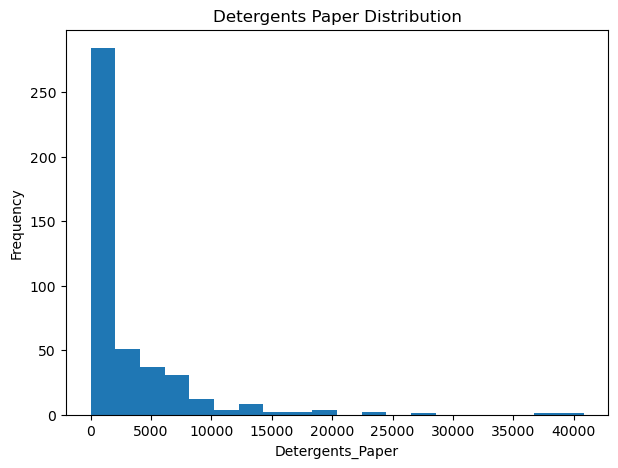

In [26]:
plt.figure(figsize=(7,5))
plt.hist(df["Detergents_Paper"], bins=20)
plt.title("Detergents Paper Distribution")
plt.xlabel("Detergents_Paper")
plt.ylabel("Frequency")
plt.show()

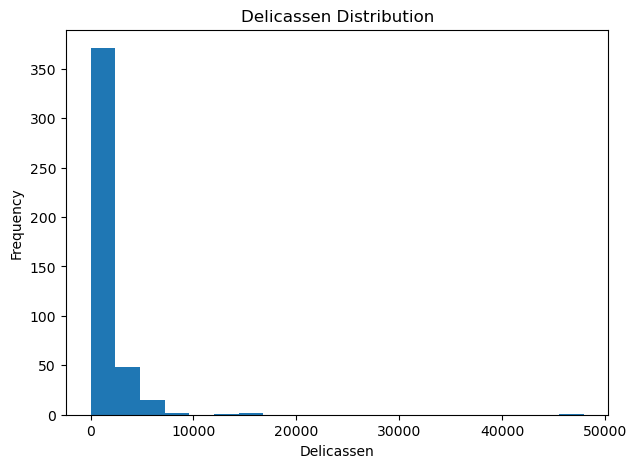

In [27]:
plt.figure(figsize=(7,5))
plt.hist(df["Delicassen"], bins=20)
plt.title("Delicassen Distribution")
plt.xlabel("Delicassen")
plt.ylabel("Frequency")
plt.show()

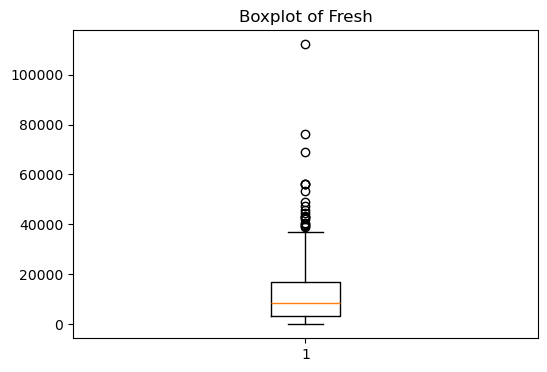

In [28]:
plt.figure(figsize=(6,4))
plt.boxplot(df["Fresh"])
plt.title("Boxplot of Fresh")
plt.show()

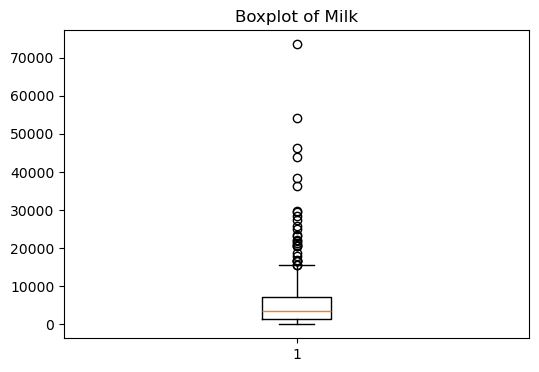

In [29]:
plt.figure(figsize=(6,4))
plt.boxplot(df["Milk"])
plt.title("Boxplot of Milk")
plt.show()

In [30]:
corr = df.corr(numeric_only=True)
corr

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Channel,1.000000,0.062028,-0.169172,0.460720,0.608792,-0.202046,0.636026,0.056011
Region,0.062028,1.000000,0.055287,0.032288,0.007696,-0.021044,-0.001483,0.045212
Fresh,-0.169172,0.055287,1.000000,0.100510,-0.011854,0.345881,-0.101953,0.244690
Milk,0.460720,0.032288,0.100510,1.000000,0.728335,0.123994,0.661816,0.406368
Grocery,0.608792,0.007696,-0.011854,0.728335,1.000000,-0.040193,0.924641,0.205497
Frozen,-0.202046,-0.021044,0.345881,0.123994,-0.040193,1.000000,-0.131525,0.390947
Detergents_Paper,0.636026,-0.001483,-0.101953,0.661816,0.924641,-0.131525,1.000000,0.069291
Delicassen,0.056011,0.045212,0.244690,0.406368,0.205497,0.390947,0.069291,1.000000


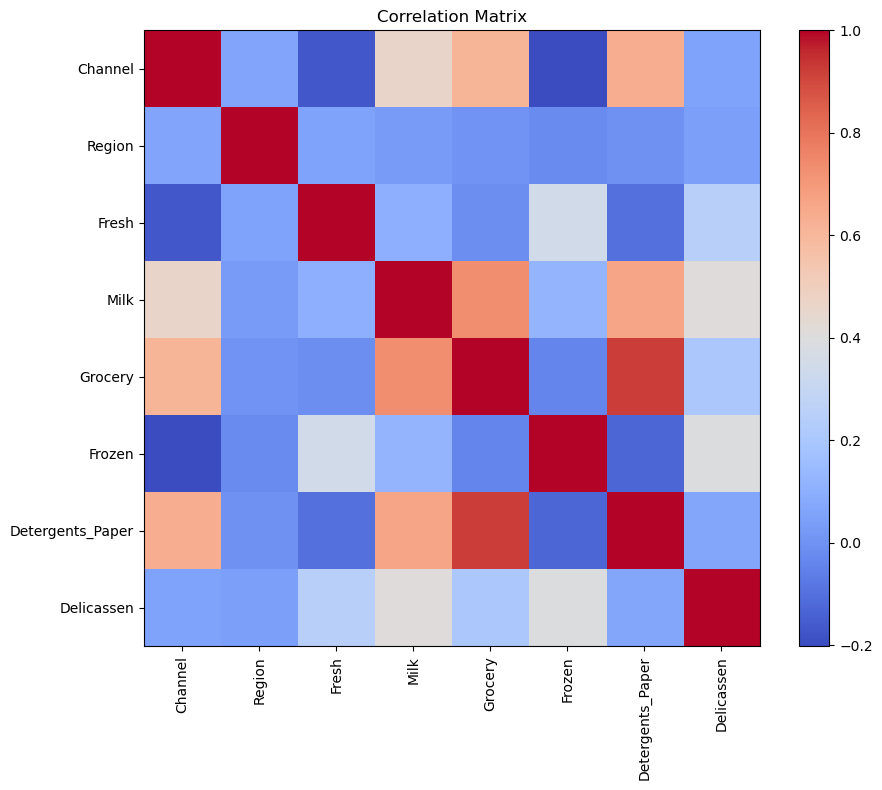

In [31]:
plt.figure(figsize=(10,8))
plt.imshow(corr, cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

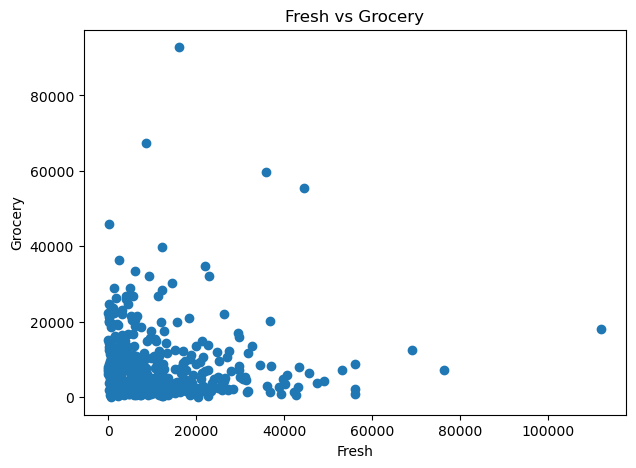

In [33]:
#Scatter Plot (Fresh vs Grocery)
plt.figure(figsize=(7,5))
plt.scatter(df["Fresh"], df["Grocery"])
plt.xlabel("Fresh")
plt.ylabel("Grocery")
plt.title("Fresh vs Grocery")
plt.show()

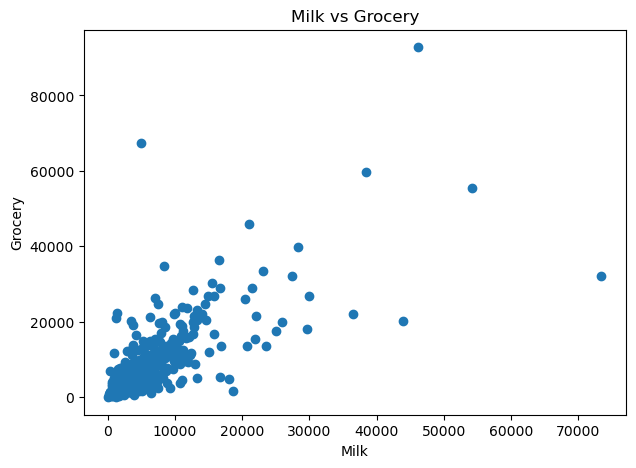

In [34]:
#Scatter Plot (Milk vs Grocery)
plt.figure(figsize=(7,5))
plt.scatter(df["Milk"], df["Grocery"])
plt.xlabel("Milk")
plt.ylabel("Grocery")
plt.title("Milk vs Grocery")
plt.show()

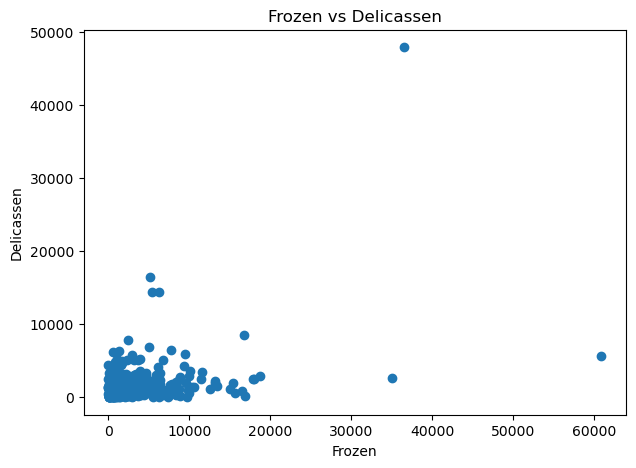

In [35]:
#Scatter Plot (Frozen vs Delicassen)
plt.figure(figsize=(7,5))
plt.scatter(df["Frozen"], df["Delicassen"])
plt.xlabel("Frozen")
plt.ylabel("Delicassen")
plt.title("Frozen vs Delicassen")
plt.show()

In [36]:
X = df.iloc[:, 2:]
X.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


In [37]:
print(X.shape)

(440, 6)


In [38]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [39]:
X_scaled[:5]

array([[ 0.05293319,  0.52356777, -0.04111489, -0.58936716, -0.04356873,
        -0.06633906],
       [-0.39130197,  0.54445767,  0.17031835, -0.27013618,  0.08640684,
         0.08915105],
       [-0.44702926,  0.40853771, -0.0281571 , -0.13753572,  0.13323164,
         2.24329255],
       [ 0.10011141, -0.62401993, -0.3929769 ,  0.6871443 , -0.49858822,
         0.09341105],
       [ 0.84023948, -0.05239645, -0.07935618,  0.17385884, -0.23191782,
         1.29934689]])

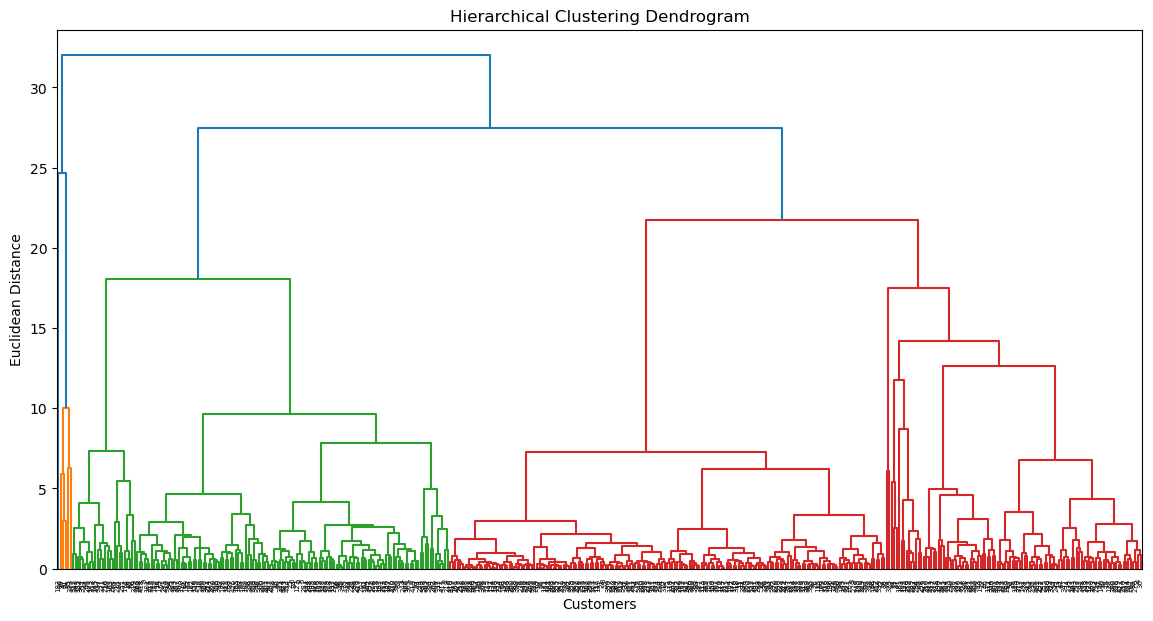

In [40]:
plt.figure(figsize=(14,7))
sch.dendrogram(sch.linkage(X_scaled,method='ward'))
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")
plt.show()

In [41]:
hc = AgglomerativeClustering(n_clusters=5,metric='euclidean',linkage='ward')
clusters = hc.fit_predict(X_scaled)

In [42]:
clusters

array([0, 0, 0, 4, 2, 0, 0, 0, 4, 0, 0, 4, 2, 2, 2, 4, 0, 0, 2, 0, 2, 4,
       2, 2, 0, 0, 4, 4, 0, 2, 2, 4, 2, 2, 4, 0, 2, 0, 0, 2, 2, 2, 0, 0,
       0, 0, 0, 1, 0, 0, 4, 4, 2, 0, 2, 4, 0, 0, 4, 0, 0, 1, 0, 0, 4, 0,
       0, 2, 4, 4, 2, 2, 4, 2, 0, 4, 4, 0, 4, 4, 4, 0, 0, 4, 0, 1, 1, 2,
       4, 2, 4, 2, 0, 2, 0, 4, 0, 4, 4, 4, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0,
       4, 0, 2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 0, 2, 2, 2, 2, 0, 2, 4, 4,
       4, 4, 4, 4, 0, 0, 2, 4, 2, 2, 2, 4, 0, 0, 4, 4, 4, 2, 4, 4, 4, 0,
       4, 0, 0, 4, 0, 0, 0, 4, 4, 0, 0, 0, 0, 4, 4, 4, 0, 0, 0, 0, 4, 0,
       2, 2, 0, 4, 2, 2, 0, 3, 4, 0, 4, 0, 0, 0, 2, 4, 4, 0, 4, 2, 2, 0,
       4, 4, 0, 0, 0, 4, 4, 0, 4, 0, 0, 0, 2, 0, 4, 0, 0, 0, 0, 4, 0, 4,
       4, 0, 4, 4, 4, 4, 2, 4, 4, 4, 2, 0, 2, 4, 2, 4, 4, 4, 4, 2, 2, 2,
       4, 2, 0, 0, 4, 4, 0, 4, 4, 0, 4, 2, 0, 2, 0, 4, 2, 2, 4, 4, 2, 4,
       0, 0, 0, 2, 0, 4, 4, 4, 0, 2, 4, 4, 2, 2, 4, 2, 4, 0, 2, 2, 2, 2,
       4, 2, 4, 2, 4, 4, 4, 0, 2, 4, 4, 0, 0, 4, 2,

In [43]:
df["Cluster"] = clusters
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster
0,2,3,12669,9656,7561,214,2674,1338,0
1,2,3,7057,9810,9568,1762,3293,1776,0
2,2,3,6353,8808,7684,2405,3516,7844,0
3,1,3,13265,1196,4221,6404,507,1788,4
4,2,3,22615,5410,7198,3915,1777,5185,2


In [44]:
df["Cluster"].value_counts().sort_index()

Cluster
0    153
1      5
2    104
3      1
4    177
Name: count, dtype: int64

In [45]:
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", round(score,3))

Silhouette Score: 0.24


In [46]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

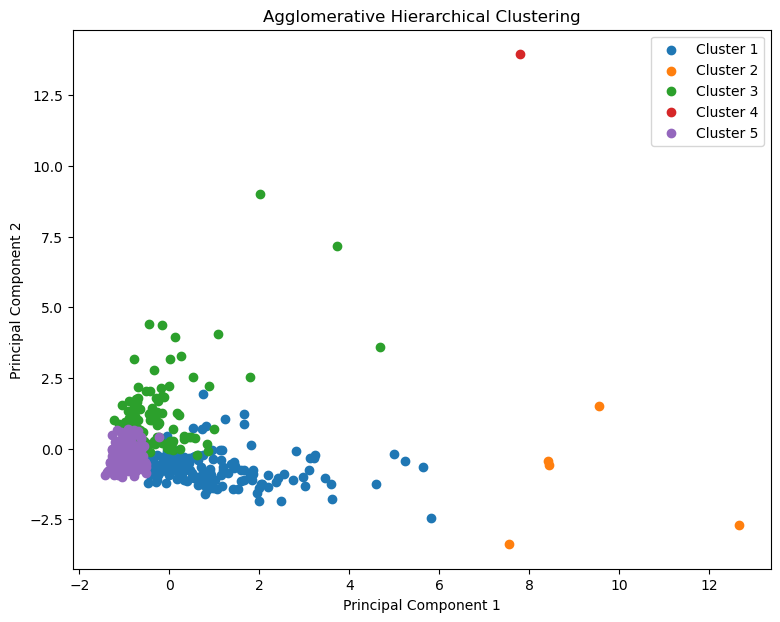

In [47]:
plt.figure(figsize=(9,7))

for i in range(5):
    plt.scatter(
        X_pca[clusters == i, 0],
        X_pca[clusters == i, 1],
        label=f'Cluster {i+1}')
plt.title("Agglomerative Hierarchical Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

In [ ]:
#
#Project Summary

#1. Loaded the Wholesale Customers dataset.
#2. Performed Exploratory Data Analysis (EDA).
#3. Checked for missing values and duplicates.
#4. Scaled the numerical features.
#5. Used a dendrogram to determine cluster structure.
#6. Applied Agglomerative Hierarchical Clustering.
#7. Evaluated the clustering using the Silhouette Score.
#8. Reduced dimensions with PCA for visualization.
#9. Saved the clustered dataset for future analysis.